# To Bee or Not To Bee — Machine Learning Project

**Course:** IG.2412

**Goal:** Classify pollinator insects (bees, bumblebees, others) from a dataset of 347 high-resolution images using extracted features and Machine Learning / Deep Learning methods.

## Pipeline
1. Load the data (images, masks, Excel labels)
2. Exploratory analysis
3. Feature extraction (III.1) — color/shape symmetry, pixel ratio, RGB stats, additional features
4. Data visualization (III.2) — class distribution, PCA, t-SNE, UMAP/Isomap
5. Machine Learning (III.3) — 2 supervised non-DL, 1 ensemble, 2 clustering, optional DL
6. Final submission CSV

## 0. Setup

In [1]:
import sys
from pathlib import Path

# Add ../src to the path so we can import our modules
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style='whitegrid')

import features
import data_loader
import visualization as viz
import models as mdl

DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

TRAIN_IMG_DIR = DATA_DIR / 'train_images'
TRAIN_MASK_DIR = DATA_DIR / 'train_masks'
TEST_IMG_DIR = DATA_DIR / 'test_images'
TEST_MASK_DIR = DATA_DIR / 'test_masks'
CLASSIF_XLSX = DATA_DIR / 'classif.xlsx'  # rename your Excel file to labels.xlsx

print('Project root:', PROJECT_ROOT)

Project root: d:\Machine learning\Projet_ML


## 1. Load the labels

In [3]:
labels = pd.read_excel(CLASSIF_XLSX)
print('Shape:', labels.shape)
labels.head()

Shape: (250, 3)


,ID,bug type,species
0,1,Bee,Apis mellifera
1,2,Bee,Apis mellifera
2,3,Bee,Apis mellifera
3,4,Bee,Apis mellifera
4,5,Bee,Apis mellifera


In [4]:
# Normalize column names just in case (handle leading/trailing spaces, capitalization)
labels.columns = [c.strip() for c in labels.columns]
print(labels.columns.tolist())
labels.head()

['ID', 'bug type', 'species']


,ID,bug type,species
0,1,Bee,Apis mellifera
1,2,Bee,Apis mellifera
2,3,Bee,Apis mellifera
3,4,Bee,Apis mellifera
4,5,Bee,Apis mellifera


## 2. Visualize a few sample images and their masks

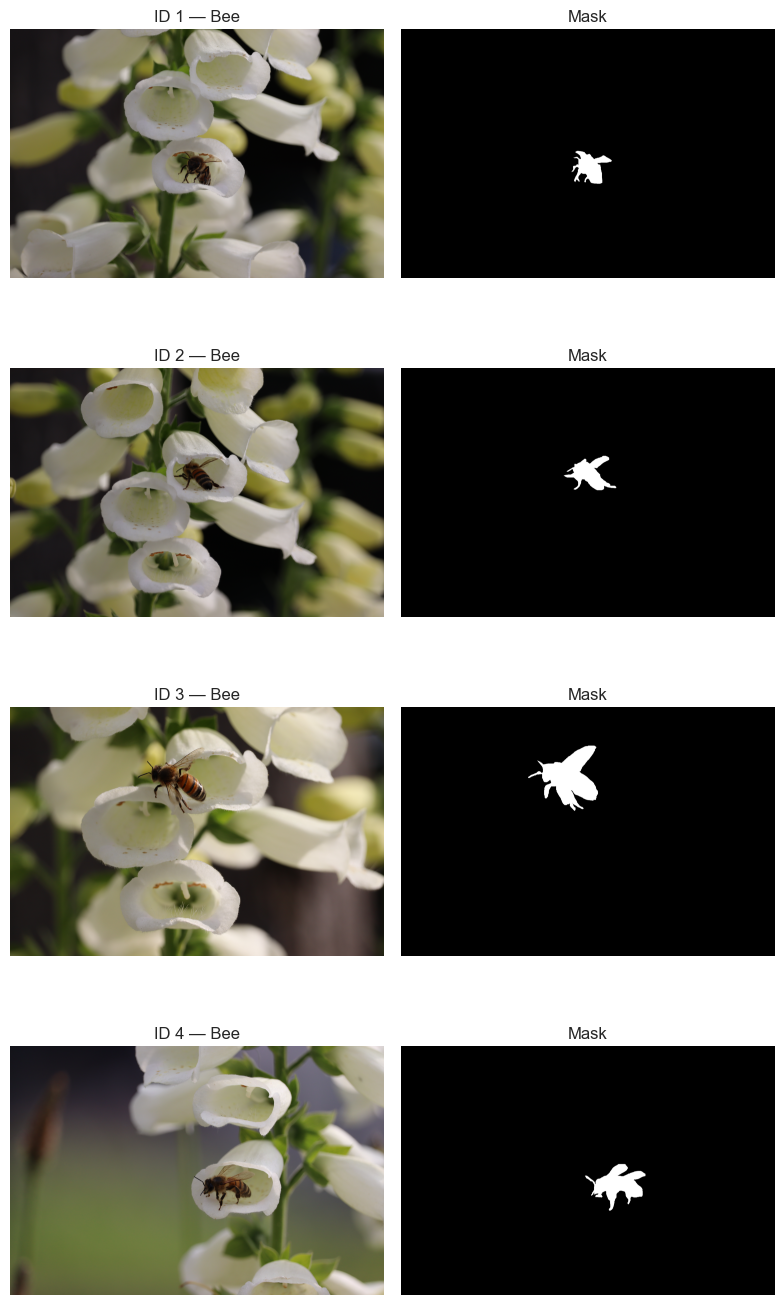

In [5]:
# Show the first 4 samples with their masks side by side
fig, axes = plt.subplots(4, 2, figsize=(8, 14))
for i, row in labels.head(4).iterrows():
    img_path, mask_path = data_loader.find_pair(TRAIN_IMG_DIR, TRAIN_MASK_DIR, row['ID'])
    if img_path is None:
        continue
    img = data_loader.load_image(img_path)
    mask = data_loader.load_mask(mask_path)
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"ID {row['ID']} — {row.get('bug type', '?')}")
    axes[i, 0].axis('off')
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title('Mask')
    axes[i, 1].axis('off')
plt.tight_layout()

## 3. Feature extraction (III.1)

We extract for every (image, mask) pair:
- **Pixel ratio**: fraction of pixels belonging to the bug
- **RGB stats inside the mask**: min, max, mean, median, std for R/G/B
- **Shape symmetry**: horizontal & vertical symmetry of the bug silhouette
- **Color symmetry**: horizontal & vertical color symmetry inside the mask
- **Additional features**: shape descriptors (aspect ratio, extent, eccentricity, solidity, compactness), HSV stats inside the mask, GLCM texture features, mean RGB of the background

In [6]:
df = data_loader.build_feature_dataframe(
    labels, TRAIN_IMG_DIR, TRAIN_MASK_DIR, id_column='ID'
)
print('Feature DataFrame shape:', df.shape)
df.head()

Extracting features:   0%|          | 0/250 [00:00<?, ?it/s]

Extracting features:  61%|██████    | 153/250 [32:35<22:19, 13.81s/it]

[warning] missing files for id=154 (img=d:\Machine learning\Projet_ML\data\train_images\154.jpg, mask=None)


Extracting features: 100%|██████████| 250/250 [42:08<00:00, 10.11s/it]

Feature DataFrame shape: (249, 41)


,ID,bug type,species,pixel_ratio,r_min,r_max,r_mean,r_median,r_std,g_min,...,hsv_s_std,hsv_v_mean,hsv_v_std,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,bg_r_mean,bg_g_mean,bg_b_mean
0,1,Bee,Apis mellifera,0.007199,5.0,203.0,66.751987,54.0,47.331705,3.0,...,0.162669,0.262071,0.185480,1.564495,0.913998,0.514596,0.969476,107.403604,105.377818,84.573148
1,2,Bee,Apis mellifera,0.008306,2.0,248.0,62.017784,54.0,41.369585,2.0,...,0.218456,0.243404,0.162159,1.309475,0.935964,0.592219,0.966940,101.106700,98.707774,74.861791
2,3,Bee,Apis mellifera,0.021768,3.0,255.0,106.613532,113.0,58.829302,0.0,...,0.240574,0.418201,0.230694,1.454544,0.911996,0.565660,0.986112,126.860688,121.479769,96.470930
3,4,Bee,Apis mellifera,0.012867,5.0,210.0,86.360405,86.0,46.082214,3.0,...,0.181673,0.338929,0.180398,1.400092,0.929950,0.581925,0.977208,113.109640,113.753378,89.642606
4,5,Bee,Apis mellifera,0.008957,6.0,255.0,121.950341,132.0,62.210226,0.0,...,0.228911,0.478319,0.243865,2.891429,0.915776,0.607399,0.975897,122.328820,120.027638,90.714724


In [7]:
# Save the features for later (so we don't have to recompute every time)
df.to_csv(OUTPUT_DIR / 'features_train.csv', index=False)
print('Features saved to', OUTPUT_DIR / 'features_train.csv')

Features saved to d:\Machine learning\Projet_ML\outputs\features_train.csv


## 4. Data visualization (III.2)

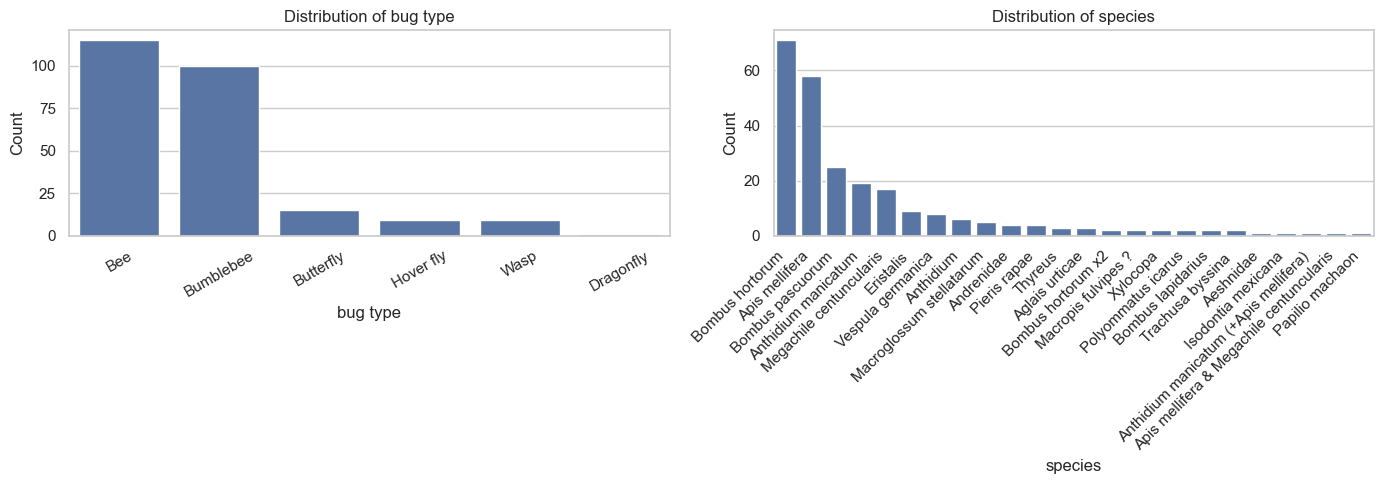

In [54]:
# 4.1 Class distribution
viz.plot_class_distribution(df, bug_type_col='bug type', species_col='species',
                            save_path=OUTPUT_DIR / 'class_distribution.png')
plt.show()

In [55]:
# Colonnes qui ne sont pas des features
label_cols = ['ID', 'bug type', 'species']
feature_cols = [c for c in df.columns
                if c not in label_cols and df[c].dtype != 'object']

# --- Données COMPLÈTES : pour le modèle final + le CSV ---
X_full = df[feature_cols].values
y_full = df['bug type'].values

# --- Données d'ÉVALUATION : classes avec >= 5 exemples (pour la CV) ---
counts = df['bug type'].value_counts()
evaluable = counts[counts >= 5].index.tolist()
df_eval = df[df['bug type'].isin(evaluable)].copy()

# X et y pointent vers les données d'évaluation.
# Ainsi, toutes les cellules de modèles ci-dessous fonctionnent SANS modification.
X = df_eval[feature_cols].values
y = df_eval['bug type'].values

print(f'{len(feature_cols)} features')
print(f'Évaluation : {len(df_eval)} images, classes = {evaluable}')
print(f'Modèle final : {len(df)} images, {df["bug type"].nunique()} classes')

38 features
Évaluation : 248 images, classes = ['Bee', 'Bumblebee', 'Butterfly', 'Hover fly', 'Wasp']
Modèle final : 249 images, 6 classes


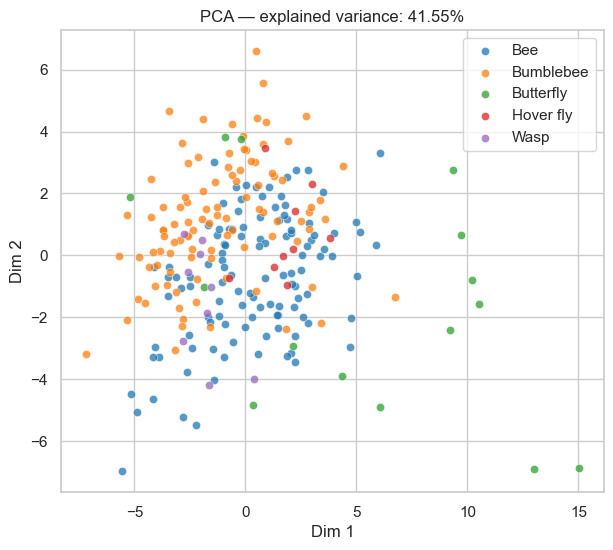

In [56]:
# 4.2 PCA
Z_pca, pca = viz.project_pca(X)
viz.plot_projection(Z_pca, y, title=f'PCA — explained variance: {pca.explained_variance_ratio_.sum():.2%}',
                    save_path=OUTPUT_DIR / 'pca.png')
plt.show()

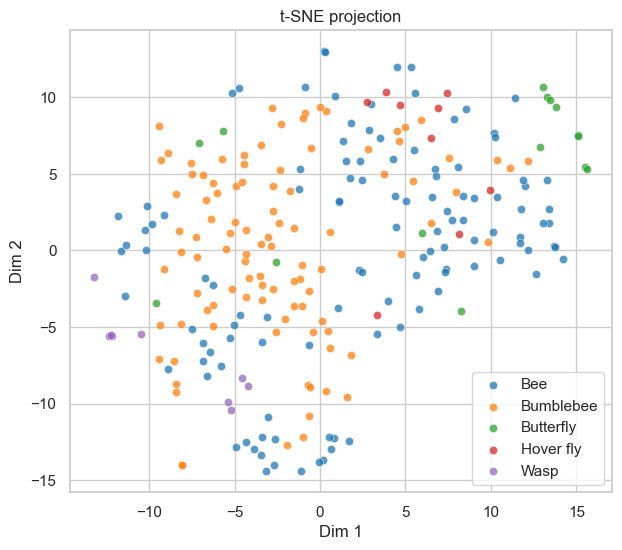

In [57]:
# 4.3 t-SNE (non-linear)
Z_tsne = viz.project_tsne(X)
viz.plot_projection(Z_tsne, y, title='t-SNE projection',
                    save_path=OUTPUT_DIR / 'tsne.png')
plt.show()

c:\Users\User\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


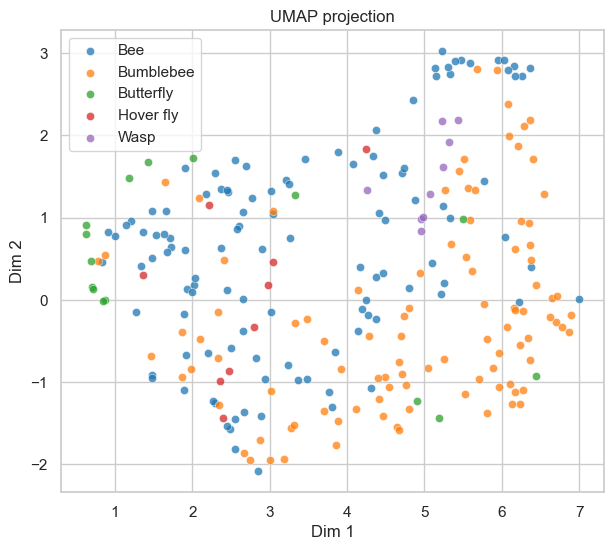

In [58]:
# 4.4 UMAP (non-linear) — falls back to Isomap if umap-learn is not installed
if viz.UMAP_AVAILABLE:
    Z_umap = viz.project_umap(X)
    title = 'UMAP projection'
    fname = 'umap.png'
else:
    Z_umap = viz.project_isomap(X)
    title = 'Isomap projection (UMAP fallback)'
    fname = 'isomap.png'
viz.plot_projection(Z_umap, y, title=title, save_path=OUTPUT_DIR / fname)
plt.show()

## 5. Machine Learning (III.3)

We target the **bug type** column (column 2), not species, because of the limited number of samples per species.

### 5.1 Two supervised methods (non-DL, non-ensemble): SVM and KNN

In [59]:
results = {}

svm = mdl.build_svm()
results['SVM'] = mdl.evaluate_supervised(svm, X, y, name='SVM (RBF)')

knn = mdl.build_knn(n_neighbors=5)
results['KNN'] = mdl.evaluate_supervised(knn, X, y, name='KNN (k=5)')


=== SVM (RBF) ===
CV accuracy: 0.770   weighted F1: 0.781
              precision    recall  f1-score   support

         Bee       0.78      0.79      0.78       115
   Bumblebee       0.87      0.80      0.83       100
   Butterfly       1.00      0.60      0.75        15
   Hover fly       0.24      0.56      0.33         9
        Wasp       0.67      0.67      0.67         9

    accuracy                           0.77       248
   macro avg       0.71      0.68      0.67       248
weighted avg       0.80      0.77      0.78       248


=== KNN (k=5) ===
CV accuracy: 0.766   weighted F1: 0.761
              precision    recall  f1-score   support

         Bee       0.73      0.83      0.78       115
   Bumblebee       0.80      0.79      0.79       100
   Butterfly       1.00      0.60      0.75        15
   Hover fly       0.40      0.22      0.29         9
        Wasp       1.00      0.56      0.71         9

    accuracy                           0.77       248
   macro avg 

### 5.2 One supervised ensemble method: Random Forest


=== Random Forest ===
CV accuracy: 0.819   weighted F1: 0.799
              precision    recall  f1-score   support

         Bee       0.77      0.92      0.84       115
   Bumblebee       0.87      0.85      0.86       100
   Butterfly       1.00      0.53      0.70        15
   Hover fly       0.00      0.00      0.00         9
        Wasp       1.00      0.44      0.62         9

    accuracy                           0.82       248
   macro avg       0.73      0.55      0.60       248
weighted avg       0.80      0.82      0.80       248



c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


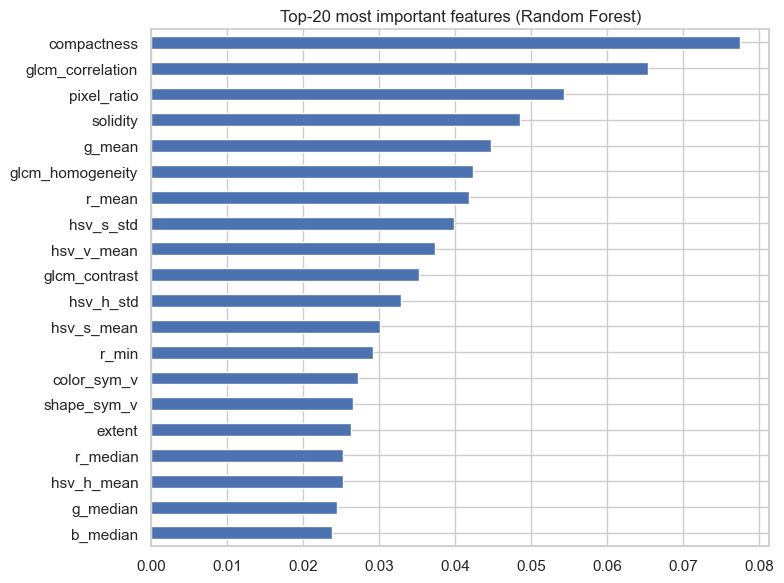

In [60]:
rf = mdl.build_random_forest()
results['RF'] = mdl.evaluate_supervised(rf, X, y, name='Random Forest')

# Feature importance from a fitted RF
rf.fit(X, y)
importances = pd.Series(rf.named_steps['clf'].feature_importances_,
                        index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
importances.head(20).plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_title('Top-20 most important features (Random Forest)')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Two clustering methods: KMeans and Agglomerative

In [61]:
n_classes = len(evaluable)   # nombre de classes évaluables
print(f'Nombre de classes : {n_classes}')

labels_km, _, Xs = mdl.cluster_kmeans(X, n_clusters=n_classes)
mdl.evaluate_clustering(y, labels_km, X=Xs, name='KMeans')

labels_ag, _, _ = mdl.cluster_agglomerative(X, n_clusters=n_classes)
mdl.evaluate_clustering(y, labels_ag, X=Xs, name='Agglomerative (ward)')

Nombre de classes : 5

=== KMeans ===
Number of clusters found: 5
Adjusted Rand Index (vs ground truth): 0.097
Normalized Mutual Information:         0.163
Silhouette score:                      0.125

=== Agglomerative (ward) ===
Number of clusters found: 5
Adjusted Rand Index (vs ground truth): 0.086
Normalized Mutual Information:         0.170
Silhouette score:                      0.085


c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


{'name': 'Agglomerative (ward)',
 'ari': 0.08568278656122535,
 'nmi': 0.16969832292749332,
 'silhouette': 0.08536714076878633}

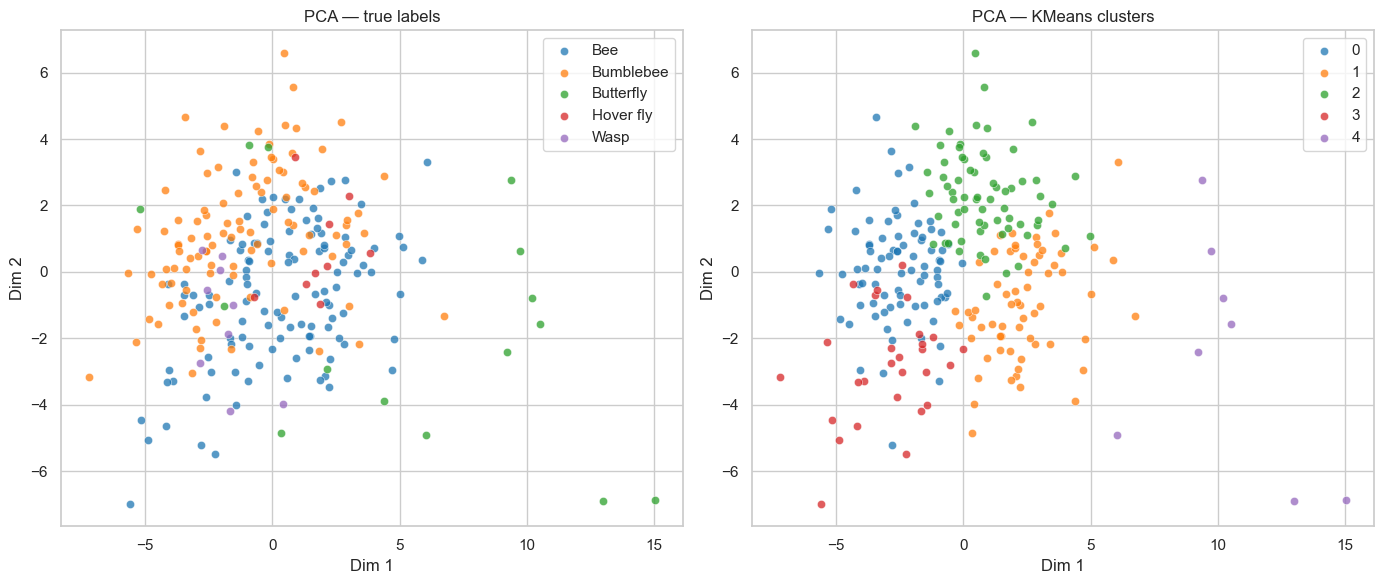

In [62]:
# Visualize the KMeans assignment on top of the PCA projection
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
viz.plot_projection(Z_pca, y, title='PCA — true labels', ax=axes[0])
viz.plot_projection(Z_pca, labels_km, title='PCA — KMeans clusters', ax=axes[1])
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'kmeans_vs_truth.png', dpi=150, bbox_inches='tight')

### 5.4 Hyperparameter tuning for the best supervised model

In [63]:
# Pick whichever model performs best in CV; here we illustrate with SVM and RF
gs_svm = mdl.tune_svm(X, y)
print('Best SVM:', gs_svm.best_params_, 'score:', gs_svm.best_score_)

gs_rf = mdl.tune_random_forest(X, y)
print('Best RF :', gs_rf.best_params_, 'score:', gs_rf.best_score_)

Best SVM: {'clf__C': 100, 'clf__gamma': 0.01} score: 0.8316347593934401
Best RF : {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 500} score: 0.8103759723028648


### 5.5 Confusion matrix of the best model

Selected model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 SVC(C=100, class_weight='balanced', gamma=0.01,
                     random_state=0))])


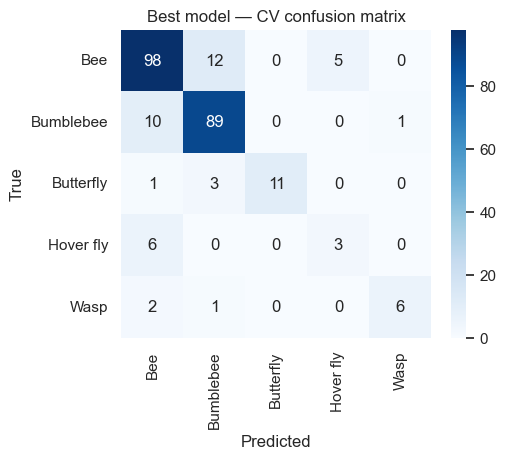

In [68]:
best_model = max([gs_svm, gs_rf], key=lambda g: g.best_score_).best_estimator_
print('Selected model:', best_model)

from sklearn.model_selection import cross_val_predict, StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
y_pred_best = cross_val_predict(best_model, X, y, cv=skf)
mdl.plot_confusion(y, y_pred_best, labels=sorted(pd.unique(y)),
                   title='Best model — CV confusion matrix',
                   save_path=OUTPUT_DIR / 'confusion_best.png')
plt.show()

## 6. Test set — extract features and produce the submission CSV

Run this section once you receive the images 251–347 and their masks.

In [ ]:
# Build a labels-like DataFrame with just the IDs of the test images
if TEST_IMG_DIR.exists():
    test_ids = sorted([int(p.stem) for p in TEST_IMG_DIR.iterdir()
                       if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}
                       and p.stem.isdigit()])
    test_labels = pd.DataFrame({'ID': test_ids})
    df_test = data_loader.build_feature_dataframe(test_labels,
                                                  TEST_IMG_DIR, TEST_MASK_DIR,
                                                  id_column='ID')
    df_test.to_csv(OUTPUT_DIR / 'features_test.csv', index=False)
    print('Test features shape:', df_test.shape)
else:
    print('Test images not available yet.')

In [ ]:
if TEST_IMG_DIR.exists() and 'df_test' in globals():
    X_test = df_test[feature_cols].values
    best_model.fit(X_full, y_full)   # entraînement final sur TOUTES les données  # final fit on all training data
    mdl.make_submission(best_model, X_test, df_test['ID'].values,
                        output_path=OUTPUT_DIR / 'submission.csv')

In [ ]:
# Vérification rapide du fichier de soumission
sub = pd.read_csv(OUTPUT_DIR / 'submission.csv')
print(f"Lignes : {len(sub)}  (attendu : 97)")
print(f"Colonnes : {list(sub.columns)}  (attendu : ['ID', 'bug type'])")
print(f"\nIDs : min={sub['ID'].min()}  max={sub['ID'].max()}")
print(f"\nRépartition prédite :")
print(sub['bug type'].value_counts())
print(f"\nPourcentages :")
print((sub['bug type'].value_counts(normalize=True) * 100).round(1))